<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Teste_com_detector_de_emo%C3%A7%C3%B5es_pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install tf_keras

In [12]:
#importando bibliotecas
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile
from tf_keras.models import load_model
import tensorflow

In [2]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [3]:
#importando recursos para o tensorflow
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

#Conexão com o Drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
#acessando e descompactando o arquivo criado
path = "/content/gdrive/My Drive/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

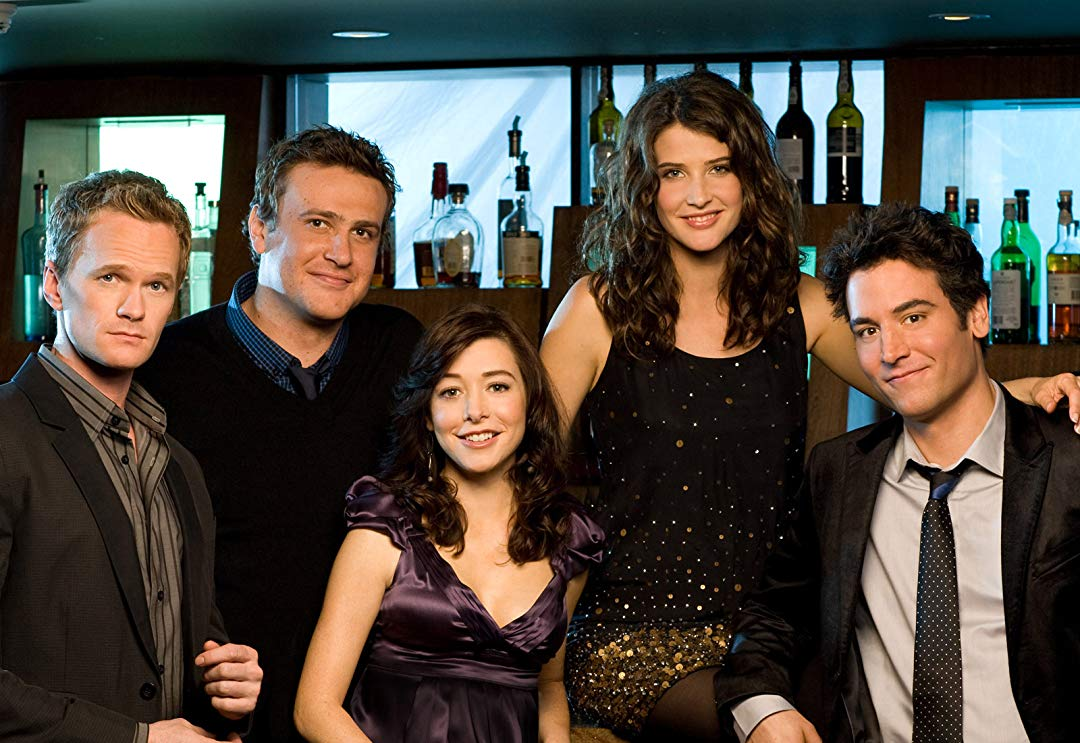

In [8]:
image = cv2.imread('Material/testes/teste05.jpg') #imagem do material de seriado
cv2_imshow(image)

In [30]:
image.shape

(743, 1080, 3)

In [36]:
original = image.copy()
faces = fase_detection.detectMultiScale(original, scaleFactor = 1.1,
                                        minNeighbors = 7, minSize = (30,30))

In [37]:
len(faces)

5

In [38]:
faces.shape

(5, 4)

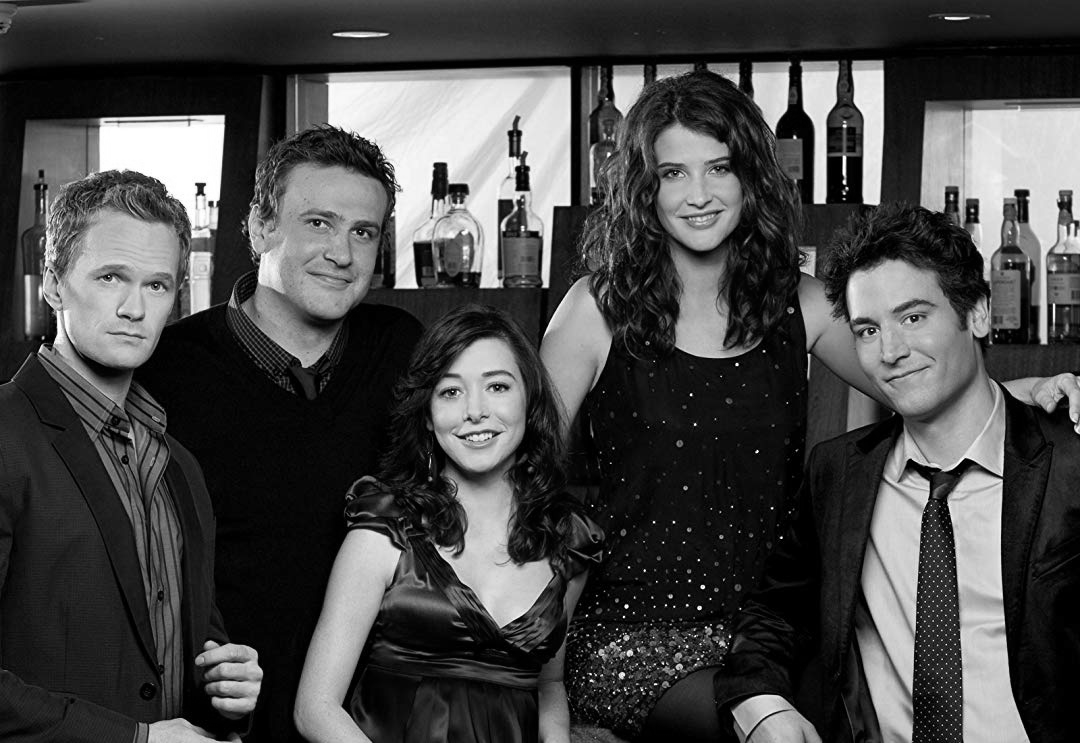

In [39]:
#Escala de cinza
cinza = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
cv2_imshow(cinza) #conversão da imagem original para cor cinza

In [40]:
cinza.shape

(743, 1080)

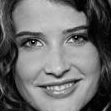

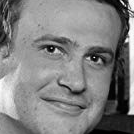

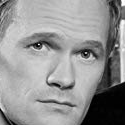

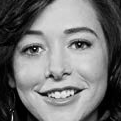

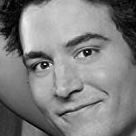

In [49]:
rostos_cinza = []

for idx, (x, y, w, h) in enumerate(faces):
  roi = cinza[y:y + h, x:x + w]
  rostos_cinza.append(roi)
  cv2_imshow(roi)
  print()

In [45]:
for idx, (x, y, w, h) in enumerate(faces):
  #extração do ROI
  roi = cinza[y:y + h, x:x + w]
  roi = cv2.resize(roi, (48, 48))
  roi = roi.astype('float')
roi = roi / 255 #normalização
roi = img_to_array(roi)
roi = np.expand_dims(roi, axis = 0)
#previsão
preds = classificador_emocoes.predict(roi)[0]
emotion_probability = np.max(preds)
label = expressoes[preds.argmax()]

1/1 [==============================] - 0s 40ms/step


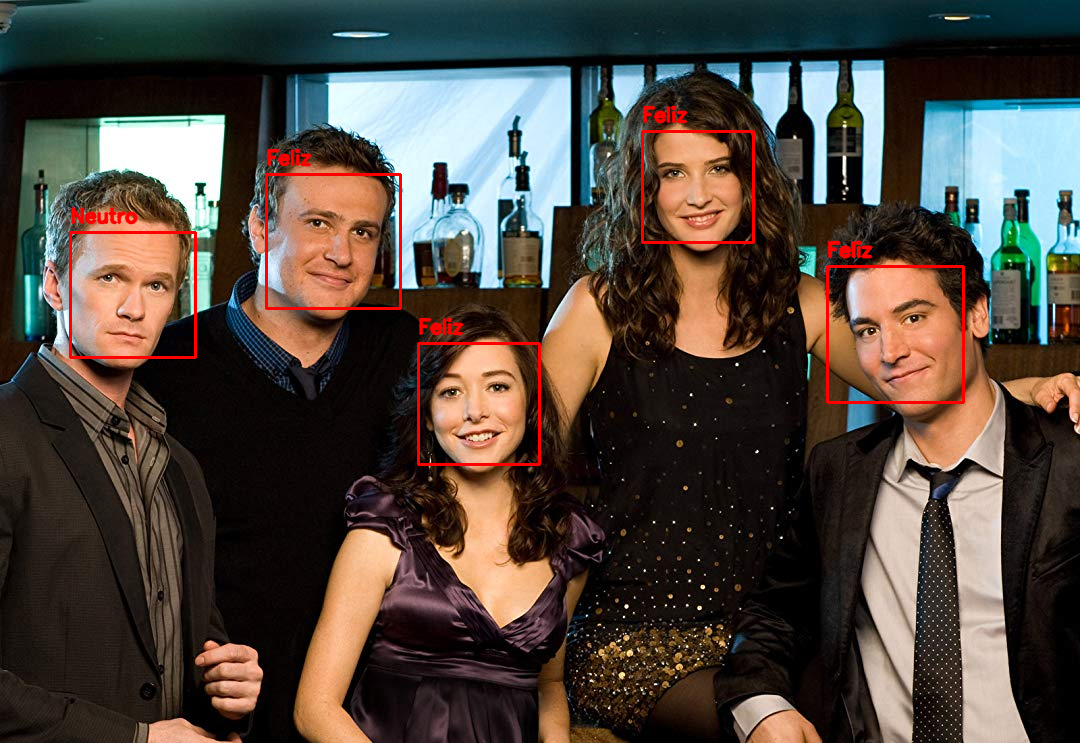

In [47]:
#desenha na imagem original
cv2.putText(original, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65,
              (0, 0, 255), 2, cv2.LINE_AA)
cv2.rectangle(original, (x, y), (x + w, y + h), (0, 0, 255), 2)

print() #linha em branco entre um rosto e outro

cv2_imshow(original)